# Cosmology with GWs/FRBs Associations MCMC version

In [1]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

### MCMCM packages
path='../FRB_cosmo/interpolation/095_C0mean.npz' # './interpolation/StandardD_C0mean.npz' 

import mcmc_support_GW_FRB
mcmc_support_GW_FRB.DATA_PATH = path
mcmc_support_GW_FRB.reload_with_path(path)
from mcmc_support_GW_FRB import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


-------------------------------------------------------------

# Table of Contents <a name="toc"></a>

1. [Basic definitions](#Definitions)
2. [Checking with Wei et al.](#Reproduction_Results_Wei_et_al)
3. [Cosmo inference without redshift - precise distance info](#Precise_distance_info)
4. [Cosmo inference without redshift - uncertain distance info](#Uncertain_distance_info)
5. [Finding the missing baryons with Macquart et al.](#Macquart_paper)

----------------------------------------------

## Basic definitions <a name="Definitions"></a>

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = \frac{(1+z) c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}}.
$$

For a cosmological constant, we have $w=-1$.

We are defining the IGM **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq. (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ - this assumes that the Universe is fully ionised at that time. For higher redshifts, the ionisation history of H and He needs to be modelled.

-----------------------------------------

## 1. $D_L$ & $DM_{diff}$ constraints <a name="D_L DM_diff"></a>

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. The mock obsersations are based on these but with scatter that follows a guassian distribution, e.g. ${\rm DM}^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

We then use the redshifts and the $\chi^2$ statistic to put constraints on $\Omega_m$ and $w$.

Return to TOC [here](#toc).

In [2]:
# Find use quadratic function may get negative error in some large redshift

def GW_error_LVK(z, H0, Om, w=-1, order=1):
    if (order==1):
        a0=19.202
        a1=86.773
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=17.015
        a1=131.750
        a2=-174.911
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')
    
def GW_error_CE(z, H0, Om, w=-1, order=2):
    if (order==1):
        a0=9.792
        a1=9.704
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=7.649
        a1=18.581
        a2=-4.559
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')

## Generate events

**For FRB DM, try to use Macquart pdf**

$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$

$$ <DM_{diff}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

$ p_{diff}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{diff}^2}\right) $

$ \sigma_{diff} $ dominated by physical variance in $DM_{diff}$

$\Delta=DM_{diff}/<DM_{diff}>$

$ \sigma_{diff}(\sigma_{\Delta}(S,z)) $

Which 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$ in Macquart paper.

Better to consider Surajit's likelihood 3 ([Surajit](https://arxiv.org/abs/2410.01974)) later. They also consider $DM_{halo}$ as a gaussian distribution

$$ DM_{halo}=\frac{1}{\sqrt{2\pi}\sigma_{halo}}\exp\left(-\frac{(DM_{halo}-\mu_{halo})^2}{2\sigma_{halo}^2}\right) $$

Take median value found in FRB cosmology project:

$S=0.02$, $\exp(\mu)=135.964$, $\sigma_{host}=0.630$, $ H_0 \Omega_b f_{diff}=2.597$. And $DM_{MW,halo}=30 pc/cm^3$

### Load interpolation

In [3]:
""" S=0.133
EXP_MU=182.937
SIGMA_HOST=0.605
DM_MWHALO=30
HOF=2.813

load_arrays=np.load('../FRB_cosmo/interpolation/095_C0mean.npz')
# load_arrays=np.load('./interpolation/StandardD_C0mean.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

sigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, 
    fill_value='extrapolate'
    )    
    
## Interpolation of C0 terms (see Macquart+ paper)
C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    fill_value='extrapolate'
    )

## Interpolation of normalisation factor (so that pdf is normalised to 1)
A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    fill_value='extrapolate'
) """

" S=0.133\nEXP_MU=182.937\nSIGMA_HOST=0.605\nDM_MWHALO=30\nHOF=2.813\n\nload_arrays=np.load('../FRB_cosmo/interpolation/095_C0mean.npz')\n# load_arrays=np.load('./interpolation/StandardD_C0mean.npz')\nSigmas=load_arrays['a']\nErrors=load_arrays['d']\nC0s=load_arrays['c']\nAs=load_arrays['b']\n\nsigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n    )    \n    \n## Interpolation of C0 terms (see Macquart+ paper)\nC0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n    )\n\n## Interpolation of normalisation factor (so that pdf is normalised to 1)\nA_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n) "

### Cosmological constraints

Generate events from $p_\Delta(\Delta)$. Note that $p_{DM_{diff}}(DM_{diff})d DM_{diff}=p_\Delta(\Delta) d\Delta$, so we have $p_{DM_{diff}}(DM_{diff})=p_\Delta(\Delta) /<DM>$

Now take into account that distances & $DM_{diff}$. To calculate the cosmological parameters, we'll follow a Bayesian approach:

$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \pi(\mathbf{H_0}) \cdot P(d_L^{\rm obs}, {\rm DM}^{\rm obs}|\mathbf{H_0}) = \\
\pi(\mathbf{H_0}) \int dz \ P\left(d_L^{\rm obs}|d_L(z,\mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) \cdot \pi(z)
$$
where with $\mathbf{H_0}$ we denote the _vector_ of cosmological parameters ($H_0, \Omega_m, w$) and $\pi(z)$ is the prior on the redshift distribution of sources and $\pi(\mathbf{H_0})$ the priors on the cosmological parameters. 

For the ${\rm DM}$ part, we can introduce the contributions of different sources as systematic errors and marginalise over them. In reality, we can estimate ${\rm DM}_{\rm diff}$ as:

$$
{\rm DM}_{\rm diff} = {\rm DM}_{\rm obs} - {\rm DM}_{\rm MW} - {\rm DM}_{\rm host}/(1+z), 
$$

where ${\rm DM}_{\rm MW} = {\rm DM}_{\rm MW, halo} + {\rm DM}_{\rm MW, ISM}$. So we can write $P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right)$ as:

$$
P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) = \int d{\rm DM}^{\rm MW} d{\rm DM}^{\rm HG} \pi({\rm DM}^{\rm MW}) \pi({\rm DM}^{\rm HG}) P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}), {\rm DM}^{\rm MW}, {\rm DM}^{\rm HG} \right).
$$

We infer:

- $H_0$ with $\Omega_m, w$ fixed to their fiducial values
- $H_0, \Omega_m$ with $w$ fixed to its fiducial value
- $H_0, \Omega_m, w$

#### Simplified version: **$p(z)\sim 1$**

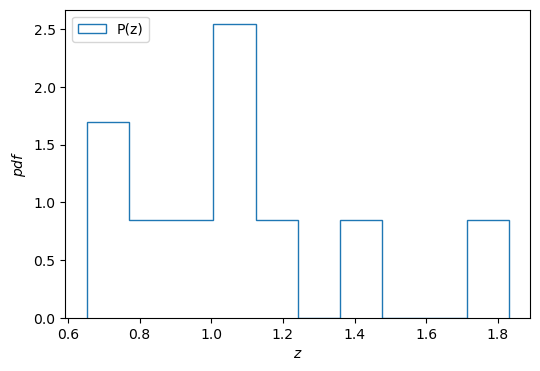

In [4]:
## Random choice of redshift
z_range = np.linspace(0.05, 2, 500)
z_centre = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=10, method='rates')

fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(z_centre, density=True, histtype='step', label='P(z)')
# ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

In [5]:
print(f"z={z_centre}")

z=[0.87064128 1.09338677 0.65180361 1.11292585 1.45681363 0.66352705
 0.90190381 1.16372745 1.83196393 1.11292585]


In [6]:
# Theoretical dL, fiducial cosmo
dL_centre = luminosity_distance(z=z_centre, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA)

# Theoretical DM, fiducial cosmo
DM_centre = dispersion_measure(z_centre, H0=HUBBLE, Om=OMEGA_MATTER)
print(f"dL={dL_centre} Mpc, DM={DM_centre} pc/cm^3")

dL=[ 5731.73522867  7588.50845813  4022.60650465  7756.138937
 10810.17928586  4110.77440582  5985.86103692  8195.22250285
 14323.45794147  7756.138937  ] Mpc, DM=[ 793.0622841   998.53320628  588.43339244 1016.36207243 1323.95374326
  599.42600155  822.11871752 1062.55115992 1645.05057047 1016.36207243] pc/cm^3


In [7]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centre
dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

DM_obs_centre=np.zeros_like(z_centre)
s_DM_obs = np.zeros_like(z_centre)

for idx, z_val in enumerate(z_centre):
    DM_obs_centre[idx], s_DM_obs[idx] = DM_diff_sampling(z=z_val, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, f_diff=0.84, f_diff_alpha=0, S=S)

print(f"dL_obs={dL_obs_centre} Mpc, DM_obs={DM_obs_centre} pc/cm^3")

/tmp/ipykernel_23864/2727814311.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  DM_obs_centre[idx], s_DM_obs[idx] = DM_diff_sampling(z=z_val, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, f_diff=0.84, f_diff_alpha=0, S=S)


dL_obs=[ 6139.45196762  8645.80609853  4024.74816909  6871.43000324
 11151.80464767  4440.43937214  5864.74180626  9293.45254897
 15243.61537756  8322.57389794] Mpc, DM_obs=[ 826.74119923 1168.5868916   547.10313108 1022.29046993 1423.60266706
  512.46399713  809.82829856 1050.63311127 1548.25248162  959.20052285] pc/cm^3


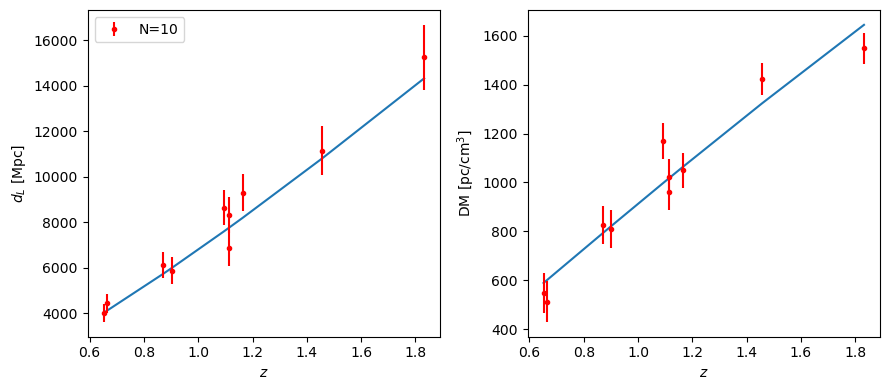

In [8]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(z_centre), np.sort(dL_centre))
ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(z_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(z_centre), np.sort(DM_centre))
ax2.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

In [9]:
events=pd.DataFrame({
    'z': z_centre,
    'dL': dL_centre,
    'dL_obs': dL_obs_centre,
    's_dL': sigma_dL,
    'DM': DM_centre,
    'DM_obs': DM_obs_centre,
    's_DM': s_DM_obs
})
events.head()

,z,dL,dL_obs,s_dL,DM,DM_obs,s_DM
0,0.870641,5731.735229,6139.451968,573.173523,793.062284,826.741199,77.955176
1,1.093387,7588.508458,8645.806099,758.850846,998.533206,1168.586892,73.248896
2,0.651804,4022.606505,4024.748169,402.260650,588.433392,547.103131,83.504231
3,1.112926,7756.138937,6871.430003,775.613894,1016.362072,1022.290470,72.873482
4,1.456814,10810.179286,11151.804648,1081.017929,1323.953743,1423.602667,67.057062


In [10]:
# initial parameters
Hubble0 = 60
Omega0 = 0.2
w0 = -1

# MCMC parameters
N_WALKERS = 32
HEATING = 2000
N_STEPS = 10000

In [11]:
# Main execution
if __name__ == "__main__":

    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([Hubble0, Omega0, w0])

    # Run MCMC
    sampler = run_mcmc(events, initial_params, nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS)

Running MCMC...
heating...


  0%|          | 0/2000 [00:00<?, ?it/s]/home/zhuge/miniconda3/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
Acceptance fraction: 0.000: 100%|██████████| 2000/2000 [17:03<00:00,  1.95it/s]


main running...


Acceptance fraction: 0.000:   6%|▌         | 601/10000 [05:07<1:35:49,  1.63it/s]

Acceptance fraction: 0.000:   7%|▋         | 701/10000 [05:57<1:31:00,  1.70it/s]

...

Acceptance fraction: 0.000:  65%|██████▌   | 6501/10000 [54:19<29:33,  1.97it/s]

Acceptance fraction: 0.000:  66%|██████▌   | 6601/10000 [55:06<27:23,  2.07it/s]

Acceptance fraction: 0.000:  67%|██████▋   | 6701/10000 [55:57<30:13,  1.82it/s]

Acceptance fraction: 0.000:  67%|██████▋   | 6737/10000 [56:17<27:15,  1.99it/s]


KeyboardInterrupt: 

In [ ]:
# Analyze results
samples, params_median, params_errors = mcmc_analyze_results(sampler, burn_in=HEATING)

# Print results
param_names = [r'$ \H_0$ ', r'$ \Omega_m$ ', r'$ w$ ']
print("MCMC Results:")
for i, name in enumerate(param_names):
    print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")

# Save samples to file for later analysis if needed
np.save('./posterior/GW_FRB_MCMC.npy', samples)

In [ ]:
param_names = [r'$ \H_0$ ', r'$ \Omega_m$ ', r'$ w$ ']
    
mcmc_plot_results(samples, param_names, savetitle=None)

# Grid search

In [30]:
### These are our priors
H0_array = np.linspace(40, 100, 100)
Omega_m_array = np.linspace(0.1, 0.5, 60)
w_array = np.linspace(-3.0, 0.0, 65)

## For 2D case
H_Om, Om_H0 = np.meshgrid(H0_array, Omega_m_array)
H_w, w_H = np.meshgrid(H0_array, w_array)
Om_w, w_Om = np.meshgrid(Omega_m_array, w_array)

## For 3D case
H_3D, Om_3D, w_3D = np.meshgrid(H0_array, Omega_m_array, w_array)

##### Only $H_0$

In [42]:
posterior_normed = np.zeros_like(H0_array)
posterior_normed_all = np.ones_like(H0_array)

### For each H0 value, we calculate the integral
for idz, z_c in enumerate(z_centre):
    dL_gaussian = np.random.normal(dL_obs_centre[idz], sigma_dL[idz], 1000)

    ## Here we are imposing a hard cut
    dL_gaussian[dL_gaussian<0]=0

    ## Fitting KDEs around the observed events
    GW_dL_kde = gaussian_kde(dL_gaussian)
    
    for i, H0 in enumerate(H0_array):
    
        ## The luminosity distance for given H0, for all z
        lum_distance = luminosity_distance(z=z_array, H0=H0, Om=OMEGA_MATTER, w=W_LAMBDA)
    
        p_DM=np.zeros_like(z_array)
        for idx, z_val in enumerate(z_array):
            DM_th=dispersion_measure(z=z_val, H0=H0, Om=OMEGA_MATTER, w=W_LAMBDA, alpha=0, f_IGM_0 = 0.84)
            error=f_variance_delta(S=S, z=z_val)

            sigma_diff=sigma_error_inter(error)
            C0=C0_sigma_inter(sigma_diff)
            A=A_sigma_inter(sigma_diff)

            p_DM[idx]=pdf_DM_cosmo(Delta=DM_obs_centre[idz]/DM_th, C_0=C0, A=A, sigma=sigma_diff, alpha=3, beta=3)/DM_th
        
        posterior_normed[i] = np.trapz(GW_dL_kde(lum_distance)*p_DM, z_array)

    ## Normalise posterior
    posterior_normed/=np.trapz(posterior_normed, H0_array)
    
    posterior_normed_all=posterior_normed_all*posterior_normed
posterior_normed_all = normalise(posterior_normed_all)

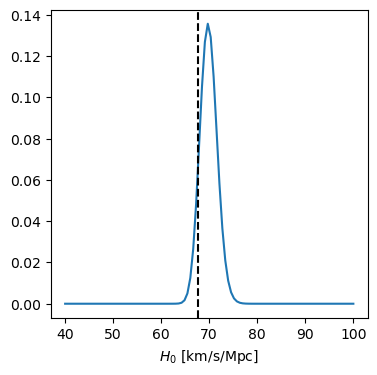

In [43]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)

ax1.plot(H0_array, posterior_normed_all, label='kde')
ax1.axvline(x=HUBBLE, ls='--', c='black')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')

plt.show()

#### $H_0$ & $\Omega_m$

In [37]:
z_array=np.linspace(0.1, 3.0, 100) ## We make this lower-res, because it creates a bottleneck

posterior_2D = np.zeros_like(H_Om)
posterior_2D_all = np.ones_like(H_Om)

total_iterations = len(z_centre) * len(H0_array) * len(Omega_m_array)

### For each H0 value, we calculate the integral
with tqdm(total=total_iterations, desc="Computing 2D posterior") as pbar:
    for idz, z_c in enumerate(z_centre):
        dL_gaussian = np.random.normal(dL_obs_centre[idz], sigma_dL[idz], 1000)

        ## Here we are imposing a hard cut
        dL_gaussian[dL_gaussian<0]=0

        ## Fitting KDEs around the observed events
        GW_dL_kde = gaussian_kde(dL_gaussian)
        
        for i, H0 in enumerate(H0_array):
            for j, Omega_m in enumerate(Omega_m_array):
                lum_distance = luminosity_distance(z=z_array, H0=H0, Om=Omega_m, w=W_LAMBDA)
        
                p_DM=np.zeros_like(z_array)
                for idx, z_val in enumerate(z_array):
                    DM_th=dispersion_measure(z=z_val, H0=H0, Om=Omega_m, w=W_LAMBDA, alpha=0, f_IGM_0 = 0.84)
                    error=f_variance_delta(S=S, z=z_val)

                    sigma_diff=sigma_error_inter(error)
                    C0=C0_sigma_inter(sigma_diff)
                    A=A_sigma_inter(sigma_diff)

                    p_DM[idx]=pdf_DM_cosmo(Delta=DM_obs_centre[idz]/DM_th, C_0=C0, A=A, sigma=sigma_diff, alpha=3, beta=3)/DM_th

                ## Integrate out the redshift dependence
                posterior_2D[j,i] = np.trapz(GW_dL_kde(lum_distance)*p_DM, z_array)
                pbar.update(1)

    ### We normalise the posterior
    total_p = np.sum(posterior_2D)
    posterior_2D_normed = posterior_2D/total_p
    
    posterior_2D_all = posterior_2D_all * posterior_2D_normed

Computing 2D posterior: 100%|██████████| 30000/30000 [07:55<00:00, 63.12it/s]


In [38]:
## Calculate the contour levels (automate the procedure with a finction)
t_contours_post2D = posterior_contour_2D(posterior_2D_all)

In [39]:
## These are already normalised (no need to normalise again, if we don't want to)

P_Om = normalise(np.sum(posterior_2D_all, axis=1))
P_H0 = normalise(np.sum(posterior_2D_all, axis=0))

/tmp/ipykernel_11197/1996090527.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues = cm.get_cmap("Blues", 10)


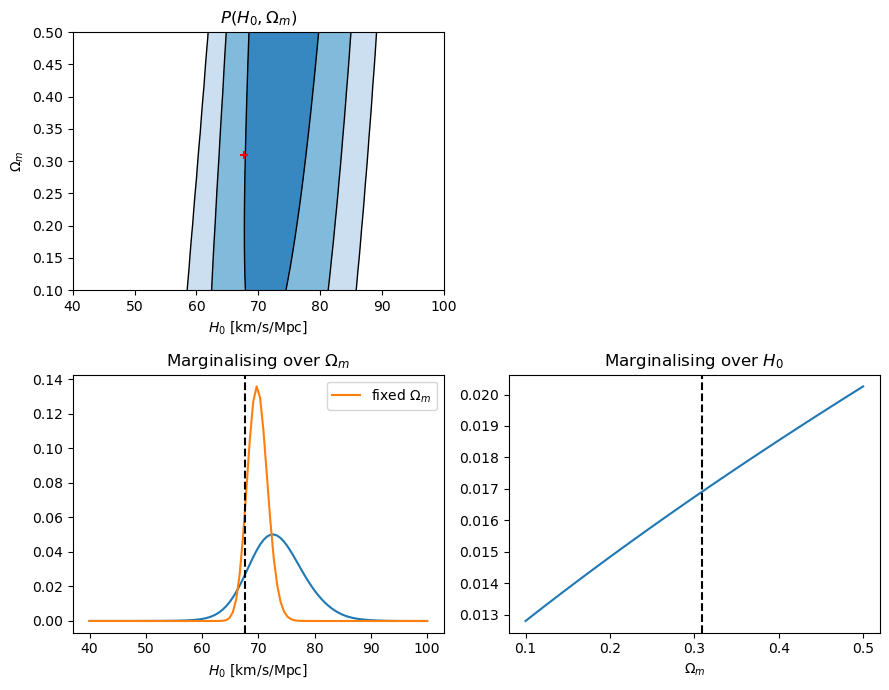

In [44]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = cm.get_cmap("Blues", 10)

ax1.contourf(H_Om, Om_H0, posterior_2D_all, levels=t_contours_post2D, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, posterior_2D_all, levels=t_contours_post2D, colors="black", linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_title(r'$P(H_0, \Omega_m)$')

ax3.plot(H0_array, P_H0)
ax3.plot(H0_array, posterior_normed_all, label=r'fixed $\Omega_m$')
ax3.axvline(x=HUBBLE, ls='--', c='black')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_title(r'Marginalising over $\Omega_m$')
ax3.legend()

ax4.plot(Omega_m_array, P_Om)
ax4.axvline(x=OMEGA_MATTER, ls='--', c='black')
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_title(r'Marginalising over $H_0$')

plt.tight_layout()
plt.show()

#### $H_0$ & $\Omega_0$ & $w$

In [ ]:
posterior_3D = np.zeros_like(H_3D)
posterior_3D_all = np.ones_like(H_3D)

total_iterations = len(z_centre) * len(H0_array) * len(Omega_m_array) * len(w_array)
pbar = tqdm(total=total_iterations, desc="Computing 3D posterior")

for idz, z_c in enumerate(z_centre):
    dL_gaussian = np.random.normal(dL_obs_centre[idz], sigma_dL[idz], 1000)

    ## Here we are imposing a hard cut
    dL_gaussian[dL_gaussian<0]=0

    ## Fitting KDEs around the observed events
    GW_dL_kde = gaussian_kde(dL_gaussian)
        
    for i, H0 in enumerate(H0_array):
        for j, Om0 in enumerate(Omega_m_array):
            for k, w0 in enumerate(w_array):
            
                lum_distance=luminosity_distance(z=z_array, H0=H0, Om=Om0, w=w0)
            
                p_DM=np.zeros_like(z_array)
                for idx, z_val in enumerate(z_array):
                    DM_th=dispersion_measure(z=z_val, H0=H0, Om=Om0, w=w0, alpha=0, f_IGM_0 = 0.84)
                    error=f_variance_delta(S=S, z=z_val)

                    sigma_diff=sigma_error_inter(error)
                    C0=C0_sigma_inter(sigma_diff)
                    A=A_sigma_inter(sigma_diff)

                    p_DM[idx]=pdf_DM_cosmo(Delta=DM_obs_centre[idz]/DM_th, C_0=C0, A=A, sigma=sigma_diff, alpha=3, beta=3)/DM_th
            
                posterior_3D[j, i, k] = np.trapz(GW_dL_kde(lum_distance)*p_DM, z_array)
                pbar.update(1)
                
    ### We normalise the posterior
    total_p = np.sum(posterior_3D)
    posterior_3D_normed = posterior_3D/total_p
    posterior_3D_all = posterior_3D_all * posterior_3D_normed
    
pbar.close()

Computing 3D posterior:   0%|          | 0/1950000 [00:00<?, ?it/s]

Computing 3D posterior:   5%|▍         | 87822/1950000 [26:24<9:52:49, 52.35it/s]

In [ ]:
Post2d_H0w = normalise(np.sum(posterior_3D_all, axis=0))
Post2d_Omw = normalise(np.sum(posterior_3D_all, axis=1))
Post2d_OmH = normalise(np.sum(posterior_3D_all, axis=2))

In [33]:
H0w_contour = posterior_contour_2D(Post2d_H0w)
Omw_contour = posterior_contour_2D(Post2d_Omw)
OmH_contour = posterior_contour_2D(Post2d_OmH)

/tmp/ipykernel_162750/4102847109.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues = cm.get_cmap("Blues", 10)


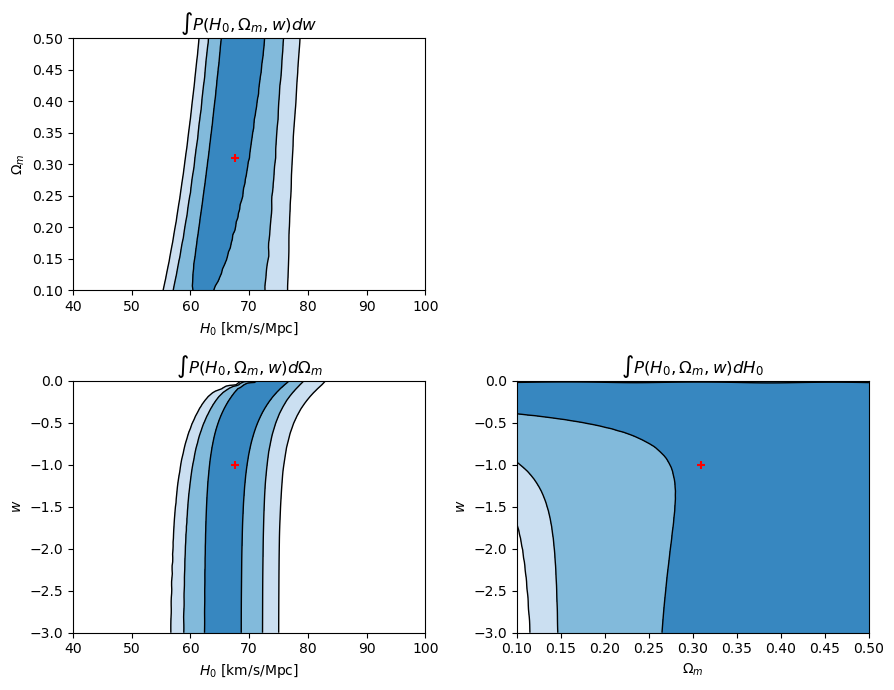

In [34]:
fig = plt.figure(figsize=(9, 7))
ax1 = fig.add_subplot(221)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

blues = cm.get_cmap("Blues", 10)

ax1.contourf(H_Om, Om_H0, Post2d_OmH, levels=OmH_contour, colors=[blues(2), blues(4), blues(6)], extend='max')
ax1.contour(H_Om, Om_H0, Post2d_OmH, levels=OmH_contour, colors="black", linewidths=1)
ax1.scatter(HUBBLE, OMEGA_MATTER, marker='+', c='r', zorder=10)
ax1.set_ylabel(r'$\Omega_m$')
ax1.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax1.set_title(r'$\int P(H_0, \Omega_m, w) dw$')

ax3.contourf(H_w, w_H, Post2d_H0w.T, levels=H0w_contour, colors=[blues(2), blues(4), blues(6)], extend='max')
ax3.contour(H_w, w_H, Post2d_H0w.T, levels=H0w_contour, colors="black", linewidths=1)
ax3.scatter(HUBBLE, W_LAMBDA, marker='+', c='r', zorder=10)
ax3.set_ylabel(r'$w$')
ax3.set_xlabel(r'$H_0$ [km/s/Mpc]')
ax3.set_title(r'$\int P(H_0, \Omega_m, w) d\Omega_m $')


ax4.contourf(Om_w, w_Om, Post2d_Omw.T, levels=Omw_contour, colors=[blues(2), blues(4), blues(6)], extend='max')
ax4.contour(Om_w, w_Om, Post2d_Omw.T, levels=Omw_contour, colors="black", linewidths=1)
ax4.scatter(OMEGA_MATTER, W_LAMBDA, marker='+', c='r', zorder=10)
ax4.set_xlabel(r'$\Omega_m$')
ax4.set_ylabel(r'$w$')
ax4.set_title(r'$\int P(H_0, \Omega_m, w) dH_0 $')

plt.tight_layout()
plt.show()

## 2. $D_L$ & $DM_{ext}$ constraints <a name="D_L DM_ext"></a> (incomplete)

Although we get good constraints for $D_L$ & $DM_{diff}$ one, this is not realistic. In observation, at least for now, $DM_{host}$ is hard to exclude from $DM_{ext}$. Thus, here we consider $DM_{obs}=DM_{ext}$ (because $DM_{MW}$ can be well extract from NE2001 or YMW16).

test

In [ ]:
dm_ext_obs=np.zeros_like(z_obs)
for idx, z in enumerate(z_obs):
    dm_range=np.linspace(0.01, 200+2*dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0, f_IGM_0 = 0.84), 2000)
    
    p_range=[
                calculate_dm_probability_num_HOf_fast(
                DM_frb_max=dm,
                z=z,
                S=S,
                HOf=HOF,
                sigma_host=SIGMA_HOST,
                e_mu=EXP_MU,
                f_sigma_error=sigma_error_inter,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter
                ) for dm in dm_range]
    
    p_range=normalise(p_range)
    
    dm_ext_obs[idx] = np.random.choice(dm_range, size=1, replace=True,\
            p=p_range
            )

/tmp/ipykernel_12211/2027467468.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dm_ext_obs[idx] = np.random.choice(dm_range, size=1, replace=True,\


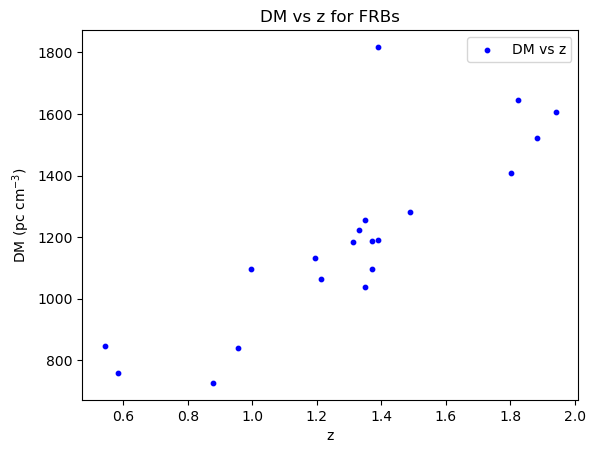

In [34]:
plt.scatter(z_obs, dm_ext_obs, label='DM vs z', color='blue', s=10)
plt.ylabel('DM (pc cm$^{-3}$)')
plt.xlabel('z')
plt.title('DM vs z for FRBs')
plt.legend()
plt.show()

In [35]:
""" def sigma_error(error):
    return error


def log_likelihood(theta, zs):
    
    dm = theta

    log_like = 0.0

    try:
        for z in zs:
            prob = calculate_dm_probability_num_HOf_fast(
                DM_frb_max=dm,
                z=z,
                S=S,
                HOf=HOF,
                sigma_host=SIGMA_HOST,
                e_mu=EXP_MU,
                f_sigma_error=sigma_error_inter,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter
            )

            if prob > 0:
                log_like += np.log(prob)
            else:
                return -np.inf

        return log_like
    except Exception as e:
        print(f"Error in log_likelihood: {e} with parameters {theta}")
        return -np.inf


def log_prior(theta):
    # Calculate the log of the prior probability for a set of parameters.

    # Args:
    #     theta: Array of parameters [F, HOf, sigma_host, e_mu]

    # Returns:
    #     Log prior probability
    dm = theta

    # Define your prior ranges here
    dm_min, dm_max = 0.012, 0.04 #  
    
    # Check if parameters are within prior ranges
    if (dm_min <= dm <= dm_max ):
        return 0.0  # Log(1) = 0, flat prior
    else:
        return -np.inf  # Log(0) = -inf, outside prior range       

def log_probability(theta, data):
    # Calculate the log probability (posterior) for a set of parameters.

    # Args:
    #     theta: Array of parameters [F, HOf, sigma_host, e_mu]
    #     data: Pandas DataFrame containing FRB data

    # Returns:
    #     Log posterior probability
    
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(theta, data)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll

def run_mcmc(data, initial_params, nwalkers=32, heating=10, nsteps=100):
    # Run the MCMC analysis.

    # Args:
    #     data: Pandas DataFrame containing FRB data
    #     initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
    #     nwalkers: Number of walkers
    #     nsteps: Number of steps per walker
    #     ndim: Number of dimensions (parameters)

    # Returns:
    #     sampler: emcee sampler object with results

    ndim=len(initial_params)

    # Set initial positions with small random offsets
    pos = initial_params + 0.1 * np.random.randn(nwalkers, ndim)
    # pos = [initial_params + _*1e-2 * np.random.randn(ndim) for _ in range(nwalkers)]

    for i in range(nwalkers):
        while log_prior(pos[i]) == -np.inf:
            pos[i] = initial_params + 0.1 * np.random.randn(ndim)

    # Set up the sampler
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_probability, 
            args=(data,), pool=pool,
            moves=[(emcee.moves.DEMove(), 0.8),
                   (emcee.moves.DESnookerMove(), 0.2)]
        )

        # Run the MCMC
        print("Running MCMC...")

        print("heating...")
        state = None
        with tqdm(total=heating) as pbar:
            for i, result in enumerate(sampler.sample(pos, iterations=heating)):
                pbar.update(1)
                state = result
                if i % 100 == 0:
                    # Calculate acceptance fraction periodically
                    acc_frac = np.mean(sampler.acceptance_fraction)
                    pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")

        print("main running...")
        with tqdm(total=nsteps) as pbar:
            for i, result in enumerate(sampler.sample(state.coords, iterations=nsteps)):
                pbar.update(1)

                # check acceptance fraction
                if i % 100 == 0:
                    acc_frac = np.mean(sampler.acceptance_fraction)
                    pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")

                    # if acceptance fraction always = 0，reset initial parameters
                    if i > 500 and acc_frac < 0.001:
                        print("warning: acceptance fraction too low，reset parameters or resun MCMC")

    # check acceptance fraction
    final_acc_frac = np.mean(sampler.acceptance_fraction)
    print(f"final acceptance fraction: {final_acc_frac:.3f}")

    if final_acc_frac < 0.01:
        print("warning: acceptance fraction too low，reset parameters or resun MCMC")

    return sampler """

' def sigma_error(error):\n    return error\n\n\ndef log_likelihood(theta, zs):\n    \n    dm = theta\n\n    log_like = 0.0\n\n    try:\n        for z in zs:\n            prob = calculate_dm_probability_num_HOf_fast(\n                DM_frb_max=dm,\n                z=z,\n                S=S,\n                HOf=HOF,\n                sigma_host=SIGMA_HOST,\n                e_mu=EXP_MU,\n                f_sigma_error=sigma_error_inter,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter\n            )\n\n            if prob > 0:\n                log_like += np.log(prob)\n            else:\n                return -np.inf\n\n        return log_like\n    except Exception as e:\n        print(f"Error in log_likelihood: {e} with parameters {theta}")\n        return -np.inf\n\n\ndef log_prior(theta):\n    # Calculate the log of the prior probability for a set of parameters.\n\n    # Args:\n    #     theta: Array of parameters [F, HOf, sigma_host, e_mu]\n\n    # Returns:\n    #     Log prior prob